# L06 : Black-hole binary formation channels with gaussian mixtures.

Load this file (np.load) and complete a quick exploration of the data.\
We'll use 'sklearn.mixture.GaussianMixture'. You first need to define the model (instance of a class), and then train it on the data using the fit method (the data provided are already in the right numpy format!). This will output the trained model, which has various attributes.\
Complete the fit 10 times with  N = 1,...,10  Gaussians.\
For each of this fits, compute the AIC (easy! It's an attribute of the trained model!). \
Plot  $N$  vs AIC: which model is preferred? \
Plot the preferred solution on top of the input data. 

In [1]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [5]:
import numpy as np
import random
import matplotlib.pyplot as plt
import astropy
import sklearn
from sklearn.mixture import GaussianMixture

In [6]:
data_path = "/Users/francescarattegni/reps/astrostatistics_bicocca_2025/solutions/formationchannels.npy"

In [7]:
data = np.load(data_path)

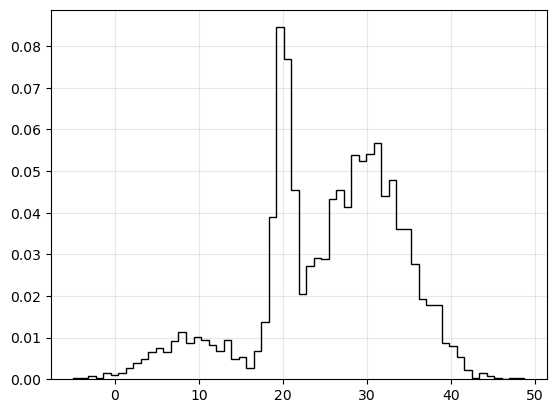

In [8]:
plt.hist(data, bins = 60, color='black', histtype='step', density=True)
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
AIC_values = []
models = {}
for i in range(1,11):
    model = sklearn.mixture.GaussianMixture(i)
    model.fit(data)
    AIC = model.aic(data)
    AIC_values.append(AIC)
    models[i] = model

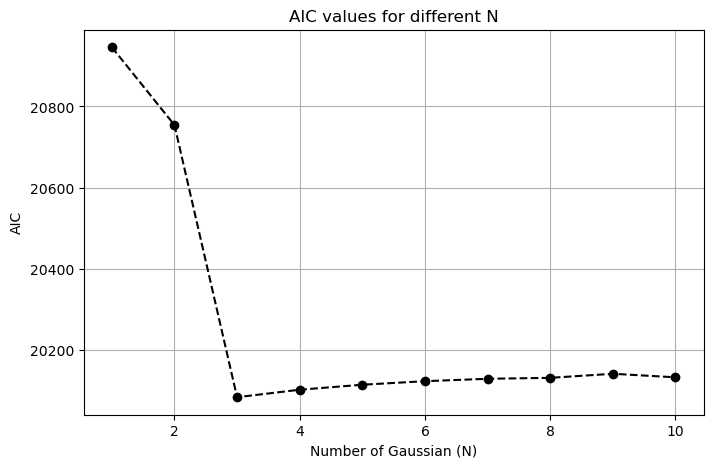

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(range(1,11), AIC_values, marker='o', color='black', linestyle='--')
plt.title("AIC values for different N")
plt.xlabel("Number of Gaussian (N)")
plt.ylabel("AIC")
plt.grid(True)
plt.show()

In [11]:
best_N = range(1, 11)[np.argmin(AIC_values)]
print("Best model :", best_N , "gaussian")

Best model : 3 gaussian


In [12]:
best_model = sklearn.mixture.GaussianMixture(best_N)
best_model.fit(data)
x = np.linspace(data.min(), data.max(), 1000).reshape(-1, 1)

log_density = best_model.score_samples(x)
density = np.exp(log_density)

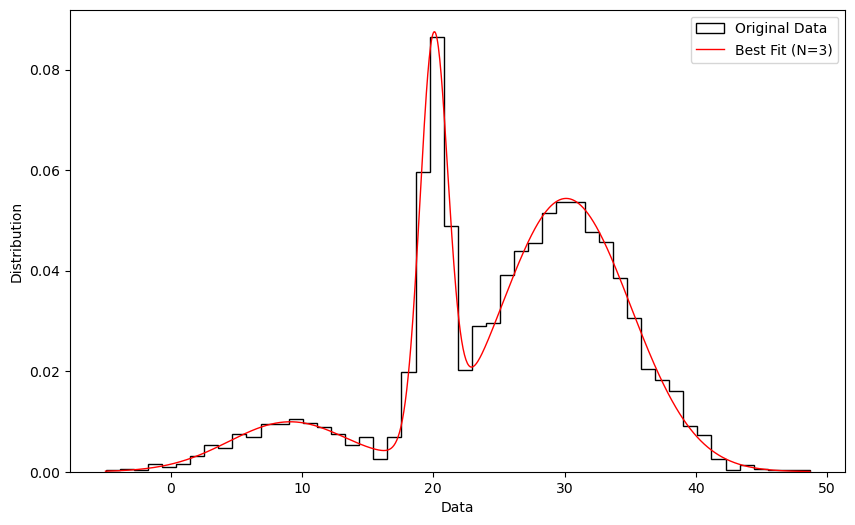

In [13]:
plt.figure(figsize=(10, 6))
plt.hist(data, bins=50, color='black', histtype='step', density=True, label='Original Data')
plt.plot(x, density, color='red', linewidth=1, label=f'Best Fit (N={best_N})')
plt.xlabel("Data")
plt.ylabel("Distribution")
plt.legend()
plt.show()

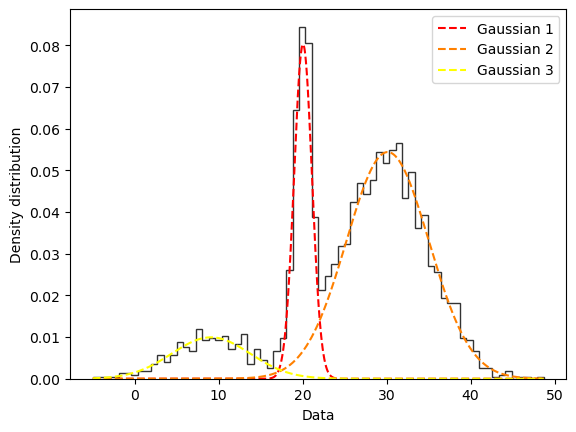

In [14]:
weights = best_model.weights_
means = best_model.means_.flatten()
covariances = best_model.covariances_.flatten()

plt.hist(data, bins=70, alpha=0.8, color='black', histtype='step', density=True)
colors = plt.cm.autumn(np.linspace(0, 1, best_N))
for i in range(best_N):
    gauss = weights[i] * (1 / np.sqrt(2 * np.pi * covariances[i])) * np.exp(-0.5 * ((x - means[i]) ** 2) / covariances[i])
    plt.plot(x, gauss, color=colors[i], linestyle='dashed', label=f'Gaussian {i+1}')

plt.xlabel("Data")
plt.ylabel("Density distribution")
plt.legend()
plt.show()